🔬 User Research Persona Analysis Tool
Generating baseline data with 10,000 users...
✓ Generated 10,000 user records

BASELINE DATA ANALYSIS
Total users: 10,000
Total attributes: 9
Theoretical max combinations: 388,800
Actual unique combinations: 9,652
Data diversity: 96.5%

Attribute Distributions:
----------------------------------------

AGE:
  26-35: 24.5%
  36-45: 20.0%
  18-25: 19.6%
  46-55: 15.4%
  56-65: 12.5%
  65+: 8.0%

INCOME:
  50-75k: 25.7%
  30-50k: 25.1%
  75-100k: 19.5%
  <30k: 14.9%
  100k+: 14.8%

EDUCATION:
  Bachelor: 34.7%
  Master: 25.0%
  Some College: 20.1%
  High School: 15.1%
  PhD: 5.2%

TECH_SAVVY:
  Medium: 50.0%
  High: 25.2%
  Low: 24.9%

DEVICE_USAGE:
  Mobile-first: 45.3%
  Multi-device: 29.6%
  Desktop-primary: 25.1%

INDUSTRY:
  Manufacturing: 20.1%
  Technology: 20.1%
  Finance: 17.9%
  Healthcare: 14.9%
  Retail: 14.9%
  Education: 12.0%

ROLE:
  Individual Contributor: 45.7%
  Manager: 29.4%
  Director: 15.1%
  Executive: 9.8%

LOCATION:
  Suburba

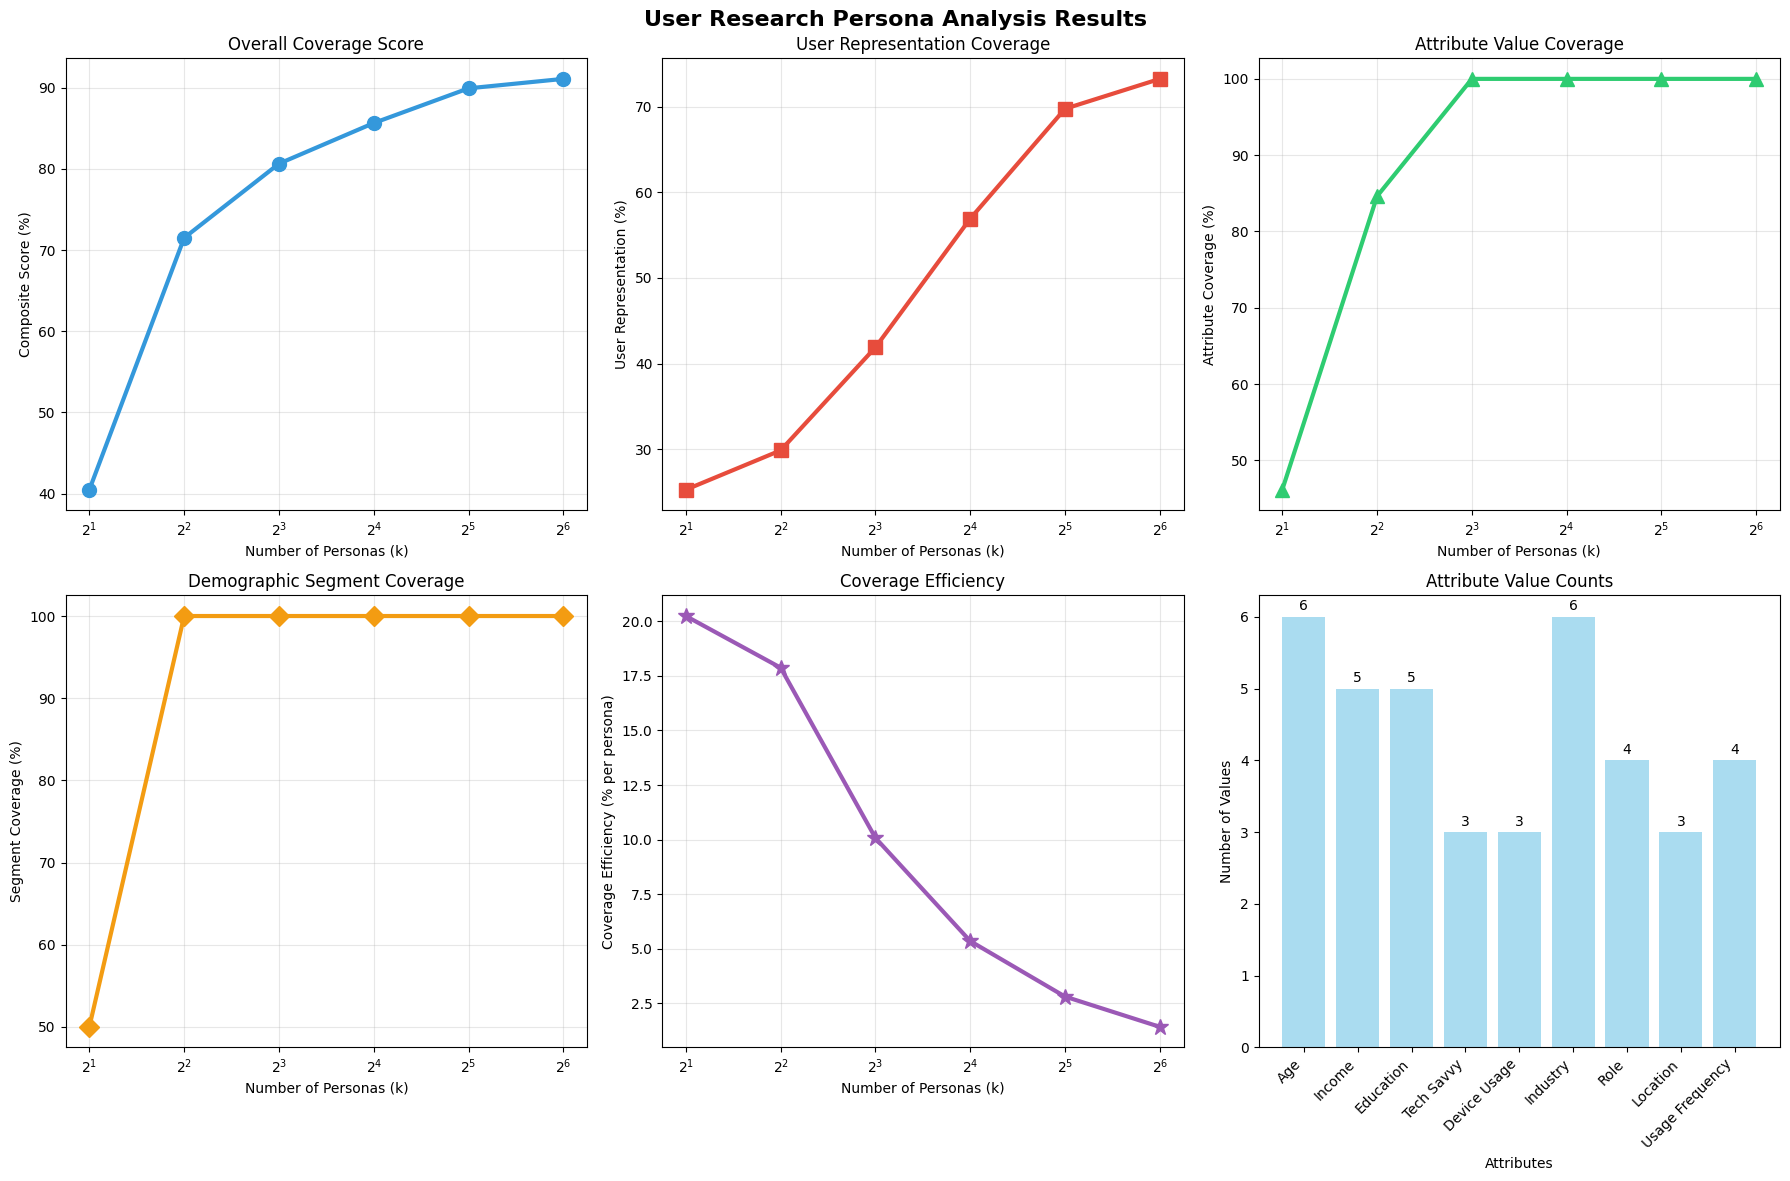


🎉 Analysis complete! Check the visualizations above.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

class UserResearchAnalyzer:
    def __init__(self):
        # Define user attributes and their possible values
        self.user_attributes = {
            'age': ['18-25', '26-35', '36-45', '46-55', '56-65', '65+'],
            'income': ['<30k', '30-50k', '50-75k', '75-100k', '100k+'],
            'education': ['High School', 'Some College', 'Bachelor', 'Master', 'PhD'],
            'tech_savvy': ['Low', 'Medium', 'High'],
            'device_usage': ['Mobile-first', 'Desktop-primary', 'Multi-device'],
            'industry': ['Healthcare', 'Education', 'Finance', 'Technology', 'Retail', 'Manufacturing'],
            'role': ['Individual Contributor', 'Manager', 'Director', 'Executive'],
            'location': ['Urban', 'Suburban', 'Rural'],
            'usage_frequency': ['Daily', 'Weekly', 'Monthly', 'Rarely']
        }

        # Define probability distributions for more realistic data
        self.distributions = {
            'age': [0.20, 0.25, 0.20, 0.15, 0.12, 0.08],
            'income': [0.15, 0.25, 0.25, 0.20, 0.15],
            'education': [0.15, 0.20, 0.35, 0.25, 0.05],
            'tech_savvy': [0.25, 0.50, 0.25],
            'device_usage': [0.45, 0.25, 0.30],
            'industry': [0.15, 0.12, 0.18, 0.20, 0.15, 0.20],
            'role': [0.45, 0.30, 0.15, 0.10],
            'location': [0.40, 0.45, 0.15],
            'usage_frequency': [0.35, 0.30, 0.20, 0.15]
        }

        self.baseline_data = None
        self.analysis_results = {}

    def generate_baseline_data(self, size=10000):
        """Generate realistic baseline user research data"""
        print(f"Generating baseline data with {size:,} users...")

        data = []
        for i in range(size):
            user = {}
            for attr, values in self.user_attributes.items():
                # Use probability distribution to select realistic values
                user[attr] = np.random.choice(values, p=self.distributions[attr])
            data.append(user)

        self.baseline_data = pd.DataFrame(data)
        print(f"✓ Generated {len(self.baseline_data):,} user records")
        return self.baseline_data

    def analyze_baseline_data(self):
        """Analyze and display baseline data statistics"""
        if self.baseline_data is None:
            raise ValueError("Generate baseline data first!")

        print("\n" + "="*60)
        print("BASELINE DATA ANALYSIS")
        print("="*60)

        print(f"Total users: {len(self.baseline_data):,}")
        print(f"Total attributes: {len(self.user_attributes)}")

        # Calculate theoretical maximum combinations
        total_combinations = 1
        for values in self.user_attributes.values():
            total_combinations *= len(values)
        print(f"Theoretical max combinations: {total_combinations:,}")

        # Calculate actual unique combinations in data
        actual_combinations = len(self.baseline_data.drop_duplicates())
        print(f"Actual unique combinations: {actual_combinations:,}")
        print(f"Data diversity: {actual_combinations/len(self.baseline_data)*100:.1f}%")

        # Show attribute distributions
        print("\nAttribute Distributions:")
        print("-" * 40)
        for attr in self.user_attributes.keys():
            print(f"\n{attr.upper()}:")
            value_counts = self.baseline_data[attr].value_counts(normalize=True)
            for value, proportion in value_counts.items():
                print(f"  {value}: {proportion*100:.1f}%")

    def create_average_personas(self, k):
        """Create personas focusing on major patterns (common attribute combinations)"""
        if self.baseline_data is None:
            raise ValueError("Generate baseline data first!")

        personas = []

        # Calculate frequency of each attribute value
        attr_frequencies = {}
        for attr in self.user_attributes.keys():
            attr_frequencies[attr] = self.baseline_data[attr].value_counts(normalize=True).to_dict()

        for i in range(k):
            persona = {'id': f'persona_{i+1}', 'name': f'User Persona {i+1}'}

            # For each attribute, select values based on frequency
            for attr, values in self.user_attributes.items():
                # Sort values by frequency (most common first)
                sorted_values = sorted(values,
                                     key=lambda x: attr_frequencies[attr].get(x, 0),
                                     reverse=True)

                # Distribute common values across personas with proper bounds checking
                value_index = i % len(sorted_values)
                persona[attr] = sorted_values[value_index]

            personas.append(persona)

        return personas

    def calculate_coverage(self, personas):
        """
        Calculate comprehensive coverage metrics:
        1. Attribute value coverage: What percentage of all possible attribute values are represented
        2. User representation: What percentage of baseline users have at least one similar persona
        3. Demographic coverage: Coverage across key demographic segments
        """
        if self.baseline_data is None:
            raise ValueError("Generate baseline data first!")

        # 1. Attribute Value Coverage
        total_possible_values = sum(len(values) for values in self.user_attributes.values())
        covered_values = set()

        for persona in personas:
            for attr, value in persona.items():
                if attr in self.user_attributes:  # Skip id and name
                    covered_values.add((attr, value))

        attribute_coverage = len(covered_values) / total_possible_values * 100

        # 2. User Representation Coverage (similarity-based)
        represented_users = 0
        similarity_threshold = 0.5  # Users need to match at least 50% of attributes with a persona

        for _, user in self.baseline_data.iterrows():
            max_similarity = 0
            for persona in personas:
                # Calculate similarity (percentage of matching attributes)
                matches = sum(1 for attr in self.user_attributes.keys()
                            if user[attr] == persona.get(attr))
                similarity = matches / len(self.user_attributes)
                max_similarity = max(max_similarity, similarity)

            if max_similarity >= similarity_threshold:
                represented_users += 1

        user_representation = represented_users / len(self.baseline_data) * 100

        # 3. Exact Combination Coverage (original metric for comparison)
        baseline_combinations = set()
        for _, row in self.baseline_data.iterrows():
            combination = tuple(row[attr] for attr in self.user_attributes.keys())
            baseline_combinations.add(combination)

        persona_combinations = set()
        for persona in personas:
            combination = tuple(persona[attr] for attr in self.user_attributes.keys())
            persona_combinations.add(combination)

        covered_combinations = baseline_combinations.intersection(persona_combinations)
        exact_coverage = len(covered_combinations) / len(baseline_combinations) * 100

        # 4. Demographic Segment Coverage
        # Define key demographic segments and check coverage
        key_segments = [
            ('age', ['18-25', '26-35']),  # Young users
            ('age', ['46-55', '56-65', '65+']),  # Older users
            ('income', ['<30k', '30-50k']),  # Lower income
            ('income', ['75-100k', '100k+']),  # Higher income
            ('tech_savvy', ['Low']),  # Low tech savvy
            ('tech_savvy', ['High']),  # High tech savvy
        ]

        covered_segments = 0
        for attr, values in key_segments:
            if any(persona.get(attr) in values for persona in personas):
                covered_segments += 1

        segment_coverage = covered_segments / len(key_segments) * 100

        coverage_metrics = {
            'attribute_coverage': attribute_coverage,
            'user_representation': user_representation,
            'exact_coverage': exact_coverage,
            'segment_coverage': segment_coverage,
            'composite_score': (attribute_coverage + user_representation + segment_coverage) / 3,
            'total_baseline_combinations': len(baseline_combinations),
            'covered_combinations': len(covered_combinations),
            'persona_combinations': len(persona_combinations),
            'unique_persona_combinations': len(persona_combinations)
        }

        return coverage_metrics

    def run_full_analysis(self, k_values=[2, 4, 8, 16, 32, 64]):
        """Run complete analysis for different k values"""
        print("\n" + "="*60)
        print("RUNNING PERSONA ANALYSIS")
        print("="*60)

        results = {
            'personas': {},
            'comparison': []
        }

        for k in k_values:
            print(f"\nAnalyzing k={k} personas...")

            try:
                # Generate personas
                personas = self.create_average_personas(k)

                # Calculate coverage
                coverage = self.calculate_coverage(personas)

                # Store results
                results['personas'][k] = {
                    'personas': personas,
                    'coverage': coverage
                }

                # Add to comparison
                results['comparison'].append({
                    'k': k,
                    'composite_score': coverage['composite_score'],
                    'attribute_coverage': coverage['attribute_coverage'],
                    'user_representation': coverage['user_representation'],
                    'segment_coverage': coverage['segment_coverage'],
                    'exact_coverage': coverage['exact_coverage'],
                    'unique_combinations': coverage['unique_persona_combinations']
                })

                print(f"  Composite score: {coverage['composite_score']:.1f}%")
                print(f"  User representation: {coverage['user_representation']:.1f}%")
                print(f"  Attribute coverage: {coverage['attribute_coverage']:.1f}%")
                print(f"  Segment coverage: {coverage['segment_coverage']:.1f}%")

            except Exception as e:
                print(f"  Error with k={k}: {str(e)}")
                continue

        self.analysis_results = results
        return results

    def display_personas(self, k=8):
        """Display generated personas for inspection"""
        if not self.analysis_results:
            raise ValueError("Run analysis first!")

        if k not in self.analysis_results['personas']:
            available_k = list(self.analysis_results['personas'].keys())
            print(f"k={k} not available. Available values: {available_k}")
            k = available_k[0] if available_k else 8

        print(f"\n" + "="*60)
        print(f"PERSONA DETAILS (k={k})")
        print("="*60)

        for persona in self.analysis_results['personas'][k]['personas']:
            print(f"\n{persona['name']} ({persona['id']}):")
            for attr in self.user_attributes.keys():
                print(f"  {attr}: {persona[attr]}")

    def create_visualizations(self):
        """Create comprehensive visualizations of the analysis"""
        if not self.analysis_results:
            raise ValueError("Run analysis first!")

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('User Research Persona Analysis Results', fontsize=16, fontweight='bold')

        # Prepare data for plotting
        comparison_df = pd.DataFrame(self.analysis_results['comparison'])

        if len(comparison_df) == 0:
            print("No data to visualize!")
            return

        # Plot 1: Composite Score
        ax1 = axes[0, 0]
        ax1.plot(comparison_df['k'], comparison_df['composite_score'],
                marker='o', linewidth=3, color='#3498db', markersize=10)
        ax1.set_xlabel('Number of Personas (k)')
        ax1.set_ylabel('Composite Score (%)')
        ax1.set_title('Overall Coverage Score')
        ax1.grid(True, alpha=0.3)
        ax1.set_xscale('log', base=2)

        # Plot 2: User Representation
        ax2 = axes[0, 1]
        ax2.plot(comparison_df['k'], comparison_df['user_representation'],
                marker='s', linewidth=3, color='#e74c3c', markersize=10)
        ax2.set_xlabel('Number of Personas (k)')
        ax2.set_ylabel('User Representation (%)')
        ax2.set_title('User Representation Coverage')
        ax2.grid(True, alpha=0.3)
        ax2.set_xscale('log', base=2)

        # Plot 3: Attribute Coverage
        ax3 = axes[0, 2]
        ax3.plot(comparison_df['k'], comparison_df['attribute_coverage'],
                marker='^', linewidth=3, color='#2ecc71', markersize=10)
        ax3.set_xlabel('Number of Personas (k)')
        ax3.set_ylabel('Attribute Coverage (%)')
        ax3.set_title('Attribute Value Coverage')
        ax3.grid(True, alpha=0.3)
        ax3.set_xscale('log', base=2)

        # Plot 4: Segment Coverage
        ax4 = axes[1, 0]
        ax4.plot(comparison_df['k'], comparison_df['segment_coverage'],
                marker='D', linewidth=3, color='#f39c12', markersize=10)
        ax4.set_xlabel('Number of Personas (k)')
        ax4.set_ylabel('Segment Coverage (%)')
        ax4.set_title('Demographic Segment Coverage')
        ax4.grid(True, alpha=0.3)
        ax4.set_xscale('log', base=2)

        # Plot 5: Coverage Efficiency (composite score per persona)
        ax5 = axes[1, 1]
        efficiency = comparison_df['composite_score'] / comparison_df['k']
        ax5.plot(comparison_df['k'], efficiency,
                marker='*', linewidth=3, color='#9b59b6', markersize=12)
        ax5.set_xlabel('Number of Personas (k)')
        ax5.set_ylabel('Coverage Efficiency (% per persona)')
        ax5.set_title('Coverage Efficiency')
        ax5.grid(True, alpha=0.3)
        ax5.set_xscale('log', base=2)

        # Plot 6: Baseline attribute distribution
        ax6 = axes[1, 2]

        # Create a simple bar chart of attribute diversity
        attr_diversity = []
        attr_names = []
        for attr, values in self.user_attributes.items():
            diversity = len(values)
            attr_diversity.append(diversity)
            attr_names.append(attr.replace('_', ' ').title())

        bars = ax6.bar(range(len(attr_names)), attr_diversity, color='skyblue', alpha=0.7)
        ax6.set_xlabel('Attributes')
        ax6.set_ylabel('Number of Values')
        ax6.set_title('Attribute Value Counts')
        ax6.set_xticks(range(len(attr_names)))
        ax6.set_xticklabels(attr_names, rotation=45, ha='right')

        # Add value labels on bars
        for bar, value in zip(bars, attr_diversity):
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{value}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

    def print_summary_table(self):
        """Print a comprehensive summary table"""
        if not self.analysis_results:
            raise ValueError("Run analysis first!")

        comparison_df = pd.DataFrame(self.analysis_results['comparison'])

        if len(comparison_df) == 0:
            print("No results to display!")
            return

        print("\n" + "="*80)
        print("PERSONA ANALYSIS SUMMARY")
        print("="*80)

        # Create formatted table
        print(f"{'k':<4} {'Composite':<10} {'User Rep':<9} {'Attribute':<10} {'Segment':<8} {'Efficiency':<11}")
        print("-" * 65)

        for _, row in comparison_df.iterrows():
            k = int(row['k'])
            composite = row['composite_score']
            user_rep = row['user_representation']
            attribute = row['attribute_coverage']
            segment = row['segment_coverage']
            efficiency = composite / k

            print(f"{k:<4} {composite:<10.1f} {user_rep:<9.1f} {attribute:<10.1f} {segment:<8.1f} {efficiency:<11.2f}")

        # Print insights
        print("\n" + "="*60)
        print("KEY INSIGHTS")
        print("="*60)

        if len(comparison_df) > 0:
            best_k = comparison_df.loc[comparison_df['composite_score'].idxmax(), 'k']
            best_score = comparison_df.loc[comparison_df['composite_score'].idxmax(), 'composite_score']

            best_efficiency_k = comparison_df.loc[(comparison_df['composite_score'] / comparison_df['k']).idxmax(), 'k']
            best_efficiency = (comparison_df['composite_score'] / comparison_df['k']).max()

            print(f"• Best overall performance: k={int(best_k)} ({best_score:.1f}% composite score)")
            print(f"• Most efficient: k={int(best_efficiency_k)} ({best_efficiency:.2f}% per persona)")

            # Coverage analysis
            first_result = list(self.analysis_results['personas'].values())[0]
            total_baseline_combinations = first_result['coverage']['total_baseline_combinations']
            total_possible_combinations = 1
            for values in self.user_attributes.values():
                total_possible_combinations *= len(values)

            print(f"• Total unique combinations in baseline: {total_baseline_combinations:,}")
            print(f"• Total theoretical combinations: {total_possible_combinations:,}")
            print(f"• Baseline diversity: {total_baseline_combinations/total_possible_combinations*100:.2f}%")

            # Recommendations
            print(f"\nRECOMMENDATIONS:")
            print(f"• For maximum coverage: Use k={int(best_k)} personas")
            print(f"• For efficiency: Use k={int(best_efficiency_k)} personas")

            # Find diminishing returns point
            efficiency_scores = comparison_df['composite_score'] / comparison_df['k']
            efficiency_diff = efficiency_scores.diff().abs()
            if len(efficiency_diff) > 1:
                diminishing_point = comparison_df.loc[efficiency_diff.idxmax(), 'k']
                print(f"• Diminishing returns start around: k={int(diminishing_point)} personas")

# Run the complete analysis
def main():
    print("🔬 User Research Persona Analysis Tool")
    print("=" * 50)

    # Initialize analyzer
    analyzer = UserResearchAnalyzer()

    # Generate baseline data
    analyzer.generate_baseline_data(size=10000)

    # Analyze baseline data
    analyzer.analyze_baseline_data()

    # Run full analysis
    results = analyzer.run_full_analysis(k_values=[2, 4, 8, 16, 32, 64])

    # Display summary
    analyzer.print_summary_table()

    # Show example personas
    analyzer.display_personas(k=8)

    # Create visualizations
    analyzer.create_visualizations()

    print("\n🎉 Analysis complete! Check the visualizations above.")

    return analyzer

# Run the analysis
if __name__ == "__main__":
    analyzer = main()